<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Lesson_6_ml_basic_assignment6-AK/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6: House Price Prediction Using Housing Data

In [ ]:
# Task 1 import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Task 2 Data Collection and Loading

# Load California Housing Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add Target Variable
df["MedHouseVal"] = housing.target

# Task 3 Quick Check of Data
print("First 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    206

**Explanation**
The California Housing dataset is loaded from Scikit-Learn and converted into a Pandas DataFrame for easier analysis.


In [ ]:
# Task 4 EDA and Data Preprocessing
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


**Interpretation**
The dataset contains no missing values.


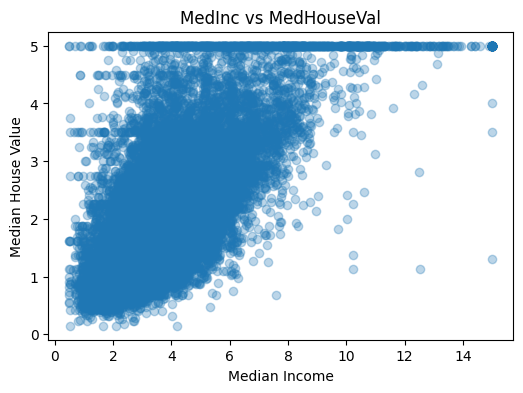

In [ ]:
# Scatter plot example
plt.figure(figsize=(6,4))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("MedInc vs MedHouseVal")
plt.show()

In [ ]:
# Function to Automate Scatter Plots
def scatter_vs_target(data, target="MedHouseVal"):

    features = [col for col in data.columns if col != target]

    for feature in features:

        plt.figure(figsize=(6,4))

        plt.scatter(
            data[feature],
            data[target],
            alpha=0.4
        )

        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")

        plt.show()


In [ ]:
# Task 5 Machine Learning Model Training
# Separate Features and Target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


Explanation

The dataset is divided into 80% Training Data and 20% Testing Data.

In [ ]:
# Train Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Explanation
Linear Regression is chosen because the target variable is continuous so it is simple and effective for regression tasks.

In [ ]:
# Task 6: Model Evaluation
# Generate Predictions
y_pred = model.predict(X_test)


In [ ]:
# Calculate RMSE
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE =", rmse)

RMSE = 0.7455813830127764


In [ ]:
# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score =", r2)

R² Score = 0.5757877060324508


Interpretation

The RMSE value of 0.745 indicates that the model's predictions are typically off by about 0.745 units from the actual house values.

An R² value of 0.58 means that the model explains approximately 58% of the variation in median house values using the selected features. The remaining 42% of the variation is due to factors not captured by the model or random variability, indicating that the model has a moderate predictive ability.


In [ ]:
# Task 7: Predict Median House Value
# New House Information
new_house = pd.DataFrame({

    "MedInc":[8.5],
    "HouseAge":[20],
    "AveRooms":[6.5],
    "AveBedrms":[1.1],
    "Population":[1200],
    "AveOccup":[3.0],
    "Latitude":[34.05],
    "Longitude":[-118.25]

})

In [ ]:
# Predict House Value
prediction = model.predict(new_house)

print(
    "Predicted Median House Value:",
    prediction[0]
)


Predicted Median House Value: 4.023831859043412


Interpretation

The model predicts a median house value of approximately $483,000.